# Stanford CME 241 (Winter 2026) - Assignment 2

**Due: Friday, February 13 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/ziyigao4/RL-book/blob/master/assignments/assignment2.ipynb

*Group members (replace below names with people in your group):* 
- Person 1
- Person 2
- Person 3

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1: Job-Hopping and Wages-Utility-Maximization (Led by ______)

You are a worker who starts every day either employed or unemployed. If you start your day employed, you work on your job for the day (one of $n$ jobs, as elaborated later) and you get to earn the wage of the job for the day. However, at the end of the day, you could lose your job with probability $\alpha \in [0,1]$, in which case you start the next day unemployed. If at the end of the day, you do not lose your job (with probability $1-\alpha$), then you will start the next day with the same job (and hence, the same daily wage). 

On the other hand, if you start your day unemployed, then you will be randomly offered one of $n$ jobs with daily wages $w_1, w_2, \ldots w_n \in \mathbb{R}^+$ with respective job-offer probabilities $p_1, p_2, \ldots p_n \in [0,1]$ (with $\sum_{i=1}^n p_i = 1$). You can choose to either accept or decline the offered job. If you accept the job offer, your day progresses exactly like the **employed-day** described above (earning the day's job wage and possibly (with probability $\alpha$) losing the job at the end of the day). However, if you decline the job offer, you spend the day unemployed, receive the unemployment wage $w_0 \in \mathbb{R}^+$ for the day, and start the next day unemployed.

The problem is to identify the optimal choice of accepting or rejecting any of the job offers the worker receives, in a manner that maximizes the infinite-horizon **Expected Discounted-Sum of Wages Utility**. Assume the daily discount factor for wages (employed or unemployed) is $\gamma \in [0,1])$. Assume Wages Utility function to be $U(w) = \log(w)$ for any wage amount $w \in \mathbb{R}^+$. The goal is to maximize:

$$
\mathbb{E}\left[\sum_{u=t}^\infty \gamma^{u-t} \cdot \log(w_{i_u})\right]
$$

at the start of a given day $t$ ($w_{i_u}$ is the wage earned on day $u$, $0 \leq i_u \leq n$ for all $u \geq t$).

---

### Subquestions

#### Part (A): MDP Modeling

Express the job-hopping problem as an MDP using clear mathematical notation by defining the following components:

1. **State Space**: Define the possible states of the MDP.
2. **Action Space**: Specify the actions available to the worker at each state.
3. **Transition Function**: Describe the probabilities of transitioning between states for each action.
4. **Reward Function**: Specify the reward associated with the states and transitions.
5. **Bellman Optimality Equation**: Write the Bellman Optimality Equation customized for this MDP.

---

#### Part (B): Python Implementation

Write Python code that:

1. Solves the Bellman Optimality Equation (hence, solves for the **Optimal Value Function** and the **Optimal Policy**) with a numerical iterative algorithm. 
2. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

*Note*: For this problem, write the algorithm from scratch without using any prebuilt MDP/DP libraries or code.

---

#### Part (C): Visualization and Analysis

1. Plot the **Optimal Value Function** as a function of the state for a specific set of parameters ($n$, $w_1, \ldots, w_n$, $p_1, \ldots, p_n$, $\alpha$, $\gamma$, $w_0$).
2. Include these graphs in your submission.

---

#### Part (D): Observations

1. What patterns do you observe in the **Optimal Policy** as you vary the parameters $n$, $\alpha$, and $\gamma$?
2. Provide a brief discussion of your findings.

---

### Part (A) Answer

We model the job-hopping problem as an infinite-horizon discounted MDP:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)
$$

---

## 1. State Space

There are $n$ jobs and one unemployment state.

$$
\mathcal{S} = \{0,1,2,\dots,n\}
$$

- $s = 0$: start of day unemployed  
- $s = i \in \{1,\dots,n\}$: start of day employed at job $i$

When unemployed, a job offer $i$ is drawn with probability $p_i$.

---

## 2. Action Space

Actions depend on the current state.

### If employed ($s=i$)

$$
\mathcal{A}(i) = \{\text{work}\}
$$

### If unemployed ($s=0$)

After observing offer $i$, the worker chooses:

$$
\mathcal{A}(0,i) = \{\text{accept}, \text{reject}\}
$$

---

## 3. Transition Function

### (a) Offer arrival when unemployed

$$
\mathbb{P}(\text{offer } i \mid s=0) = p_i, \quad i=1,\dots,n
$$

### (b) If working at job $i$

At end of day:

$$
\mathbb{P}(i \mid i, \text{work}) = 1-\alpha
$$

$$
\mathbb{P}(0 \mid i, \text{work}) = \alpha
$$

### (c) If accepting offer $i$

$$
\mathbb{P}(i \mid 0,i,\text{accept}) = 1-\alpha
$$

$$
\mathbb{P}(0 \mid 0,i,\text{accept}) = \alpha
$$

### (d) If rejecting offer

$$
\mathbb{P}(0 \mid 0,i,\text{reject}) = 1
$$

---

## 4. Reward Function

Utility is logarithmic:

$$
U(w) = \log(w)
$$

Rewards:

If working job $i$:

$$
r(i,\text{work}) = \log(w_i)
$$

If accepting offer $i$:

$$
r(0,i,\text{accept}) = \log(w_i)
$$

If rejecting:

$$
r(0,i,\text{reject}) = \log(w_0)
$$

---

## 5. Bellman Optimality Equations

Let $V^*(0)$ be the value when starting the day unemployed, and $V^*(i)$ the value when starting employed at job $i$.

### Employed state $i$

$$
V^*(i)
=
\log(w_i)
+
\gamma\Big((1-\alpha)V^*(i) + \alpha V^*(0)\Big),
\quad i=1,\dots,n
$$

### Unemployed state

$$
V^*(0)
=
\sum_{i=1}^n
p_i
\max\Big\{
\log(w_i) + \gamma\big((1-\alpha)V^*(i) + \alpha V^*(0)\big),
\;
\log(w_0) + \gamma V^*(0)
\Big\}
$$


### Part (B) Answer

In [2]:
import math
from typing import List, Tuple


def solve_job_hopping(
    w0: float,
    wages: List[float],
    probs: List[float],
    alpha: float,
    gamma: float,
    tol: float = 1e-10,
    max_iter: int = 100000
) -> Tuple[float, List[float], List[bool]]:


    n = len(wages)

    # Precompute logs
    logw0 = math.log(w0)
    logw = [0.0] + [math.log(w) for w in wages]  # 1-indexed

    # Initialize values
    V0 = logw0 / (1 - gamma)
    V = [0.0] * (n + 1)
    for i in range(1, n + 1):
        V[i] = logw[i] / (1 - gamma)

    denom = 1 - gamma * (1 - alpha)

    for _ in range(max_iter):

        V0_old = V0
        V_old = V.copy()

        # Update employed states
        for i in range(1, n + 1):
            V[i] = (logw[i] + gamma * alpha * V0_old) / denom

        # Update unemployed state
        reject_val = logw0 + gamma * V0_old

        V0_new = 0.0
        for i in range(1, n + 1):
            accept_val = logw[i] + gamma * ((1 - alpha) * V[i] + alpha * V0_old)
            V0_new += probs[i - 1] * max(accept_val, reject_val)

        V0 = V0_new

        # Check convergence
        diff = abs(V0 - V0_old)
        for i in range(1, n + 1):
            diff = max(diff, abs(V[i] - V_old[i]))

        if diff < tol:
            break

    # Extract optimal policy
    accept = [False] * (n + 1)
    reject_val = logw0 + gamma * V0

    for i in range(1, n + 1):
        accept_val = logw[i] + gamma * ((1 - alpha) * V[i] + alpha * V0)
        accept[i] = accept_val >= reject_val

    return V0, V, accept


### Part (C) Answer

<span style="color:red">*fill in*</span>

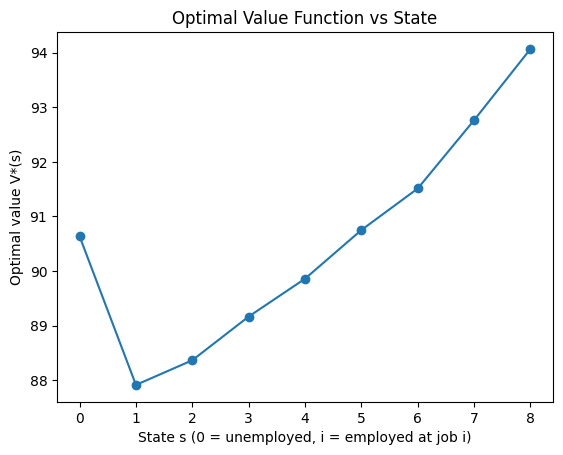

In [6]:
n = 8
w0 = 50.0
wages = [55.0, 60.0, 70.0, 80.0, 95.0, 110.0, 140.0, 180.0]
probs = [0.18, 0.18, 0.16, 0.14, 0.12, 0.10, 0.08, 0.04]
alpha = 0.15
gamma = 0.95

V0, V, policy = solve_job_hopping(w0, wages, probs, alpha, gamma)

states = list(range(0, n + 1))
values = [V0] + [V[i] for i in range(1, n + 1)]

plt.figure()
plt.plot(states, values, marker="o")
plt.xlabel("State s (0 = unemployed, i = employed at job i)")
plt.ylabel("Optimal value V*(s)")
plt.title("Optimal Value Function vs State")
plt.xticks(states)
plt.show()


### Part (D) Answer

<span style="color:red">*fill in*</span>

In [4]:
alphas = [0.05, 0.2, 0.5]

for a in alphas:
    V0, V, policy = solve_job_hopping(w0, wages, probs, a, gamma)
    accepted_jobs = sum(policy[1:])
    print(f"alpha={a:.2f}, accepted jobs = {accepted_jobs}")


alpha=0.05, accepted jobs = 3
alpha=0.20, accepted jobs = 5
alpha=0.50, accepted jobs = 6


In [8]:
gammas = [0.85, 0.95, 0.99]

for g in gammas:
    V0, V, policy = solve_job_hopping(w0, wages, probs, alpha, g)
    accepted_jobs = sum(policy[1:])
    print(f"gamma={g:.2f}, accepted jobs = {accepted_jobs}")


gamma=0.85, accepted jobs = 5
gamma=0.95, accepted jobs = 4
gamma=0.99, accepted jobs = 4


#### 1) Varying $n$ (number of possible jobs)

- **More high-wage “tail” jobs (larger $n$ with some large $w_i$)** typically makes the worker **more selective**:
  - because the option value of waiting increases (you might get a better draw tomorrow).
- If increasing $n$ only adds **more low-wage jobs** (mass added below the current acceptance threshold), the policy for existing wages is mostly unchanged, but the worker rejects those new low-wage offers.

Net effect: **$n$ matters mainly through the wage distribution and probabilities**; richer upside increases selectivity.

---

#### 2) Varying $\alpha$ (job-loss probability)

- As $\alpha$ increases (jobs become less stable), the worker becomes **less selective** and tends to **accept more offers**.
  - Reason: the benefit of holding out for a great job is reduced, since even after accepting, you are likely to lose it soon.
- As $\alpha$ decreases (jobs become more stable), the worker becomes **more selective**:
  - a high-wage job is more valuable because you expect to keep it longer.

Net effect: higher $\alpha$ $\Rightarrow$ **lower “reservation wage”**; lower $\alpha$ $\Rightarrow$ **higher reservation wage**.

---

#### 3) Varying $\gamma$ (discount factor)

- As $\gamma$ increases (more patient / future matters more), the worker becomes **more selective**:
  - the value of waiting for a better offer rises because future utility is discounted less.
- As $\gamma$ decreases (more myopic), the worker becomes **less selective**:
  - today’s wage dominates, so accepting “okay” offers is more attractive than waiting.

Net effect: higher $\gamma$ $\Rightarrow$ **higher reservation wage**; lower $\gamma$ $\Rightarrow$ **lower reservation wage**.

---


## Question 2: Two-Stores Inventory Control (Led by ______)

We extend the capacity-constrained inventory example implemented in [rl/chapter3/simple_inventory_mdp_cap.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/chapter3/simple_inventory_mdp_cap.py) as a `FiniteMarkovDecisionProcess` (the Finite MDP model for the capacity-constrained inventory example is described in detail in Chapters 1 and 2 of the RLForFinanceBook). Here we assume that we have two different stores, each with their own separate capacities $C_1$ and $C_2$, their own separate Poisson probability distributions of demand (with means $\lambda_1$ and $\lambda_2$), their own separate holding costs $h_1$ and $h_2$, and their own separate stockout costs $p_1$ and $p_2$. At 6pm upon stores closing each evening, each store can choose to order inventory from a common supplier (as usual, ordered inventory will arrive at the store 36 hours later). We are also allowed to transfer inventory from one store to another, and any such transfer happens overnight, i.e., will arrive by 6am next morning (since the stores are fairly close to each other). Note that the orders are constrained such that following the orders on each evening, each store's inventory position (sum of on-hand inventory and on-order inventory) cannot exceed the store's capacity (this means the action space is constrained to be finite). Each order made to the supplier incurs a fixed transportation cost of $K_1$ (fixed-cost means the cost is the same no matter how many units of non-zero inventory a particular store orders). Moving any non-zero inventory between the two stores incurs a fixed transportation cost of $K_2$. 

Model this as a derived class of `FiniteMarkovDecisionProcess` much like we did for `SimpleInventoryMDPCap` in the code repo. Set up instances of this derived class for different choices of the problem parameters (capacities, costs etc.), and determine the Optimal Value Function and Optimal Policy by invoking the function `value_iteration` (or `policy_iteration`) from file [rl/dynamic_programming.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/dynamic_programming.py).

Analyze the obtained Optimal Policy and verify that it makes intuitive sense as a function of the problem parameters.

In [10]:
import sys
import os

# Add project root (RL-book) to Python path
sys.path.append(os.path.abspath(".."))

In [11]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple, Iterable, List
from collections import defaultdict
import math

import matplotlib.pyplot as plt
from scipy.stats import poisson

from rl.distribution import Categorical
from rl.markov_process import NonTerminal, Terminal
from rl.dynamic_programming import value_iteration
from rl.markov_decision_process import FiniteMarkovDecisionProcess


In [12]:
@dataclass(frozen=True)
class TwoStoreState:
    a1: int
    b1: int
    a2: int
    b2: int

    def ip1(self) -> int:
        return self.a1 + self.b1

    def ip2(self) -> int:
        return self.a2 + self.b2


@dataclass(frozen=True)
class TwoStoreAction:
    order1: int
    order2: int
    transfer: int


def poisson_tail_cond_mean(lam: float, k: int) -> float:
    if k <= 0:
        return lam
    distr = poisson(lam)
    tail_k = float(distr.sf(k - 1))     # P(D >= k)
    if tail_k <= 0.0:
        return float(k)
    tail_km1 = float(distr.sf(k - 2))   # P(D >= k-1)
    return lam * (tail_km1 / tail_k)


In [13]:
class TwoStoreInventoryMDPCap(FiniteMarkovDecisionProcess[TwoStoreState, TwoStoreAction]):

    def __init__(
        self,
        C1: int, C2: int,
        lambda1: float, lambda2: float,
        h1: float, h2: float,
        p1: float, p2: float,
        K1: float, K2: float
    ):
        self.C1 = int(C1)
        self.C2 = int(C2)
        self.lambda1 = float(lambda1)
        self.lambda2 = float(lambda2)
        self.h1 = float(h1)
        self.h2 = float(h2)
        self.p1 = float(p1)
        self.p2 = float(p2)
        self.K1 = float(K1)
        self.K2 = float(K2)

        self.poiss1 = poisson(self.lambda1)
        self.poiss2 = poisson(self.lambda2)

        super().__init__(self.get_action_transition_reward_map())

    def actions_for_state(self, s: TwoStoreState) -> Iterable[TwoStoreAction]:
        a1, b1, a2, b2 = s.a1, s.b1, s.a2, s.b2

        # transfer bounds:
        # t > 0 : 1->2, t <= a1
        # t < 0 : 2->1, |t| <= a2
        for t in range(-a2, a1 + 1):
            a1_t = a1 - t
            a2_t = a2 + t
            if a1_t < 0 or a2_t < 0:
                continue

            ip1 = a1_t + b1
            ip2 = a2_t + b2
            if ip1 > self.C1 or ip2 > self.C2:
                continue

            max_o1 = self.C1 - ip1
            max_o2 = self.C2 - ip2
            for o1 in range(max_o1 + 1):
                for o2 in range(max_o2 + 1):
                    yield TwoStoreAction(order1=o1, order2=o2, transfer=t)

    def one_store_outcomes(
        self, ip: int, order: int, lam: float, h: float, p: float
    ) -> Dict[Tuple[int, int, float], float]:
        distr = poisson(lam)
        out: Dict[Tuple[int, int, float], float] = {}

        # explicit d < ip
        for d in range(ip):
            prob = float(distr.pmf(d))
            a_next = ip - d
            reward = -h * a_next
            out[(a_next, order, reward)] = prob

        # tail d >= ip
        tail_prob = float(distr.sf(ip - 1))
        if tail_prob > 0.0:
            cond_mean = poisson_tail_cond_mean(lam, ip)  # E[D | D>=ip]
            expected_stockout = max(cond_mean - ip, 0.0)
            reward_tail = -p * expected_stockout
            out[(0, order, reward_tail)] = tail_prob

        # normalize (numerical safety)
        total = sum(out.values())
        for k in list(out.keys()):
            out[k] = out[k] / total

        return out

    def get_action_transition_reward_map(self):
        d: Dict[TwoStoreState, Dict[TwoStoreAction, Categorical[Tuple[TwoStoreState, float]]]] = {}

        # enumerate feasible states under capacity
        for a1 in range(self.C1 + 1):
            for b1 in range(self.C1 + 1 - a1):
                for a2 in range(self.C2 + 1):
                    for b2 in range(self.C2 + 1 - a2):
                        s = TwoStoreState(a1, b1, a2, b2)
                        action_map: Dict[TwoStoreAction, Categorical[Tuple[TwoStoreState, float]]] = {}

                        for act in self.actions_for_state(s):
                            # apply transfer before demand
                            a1_t = s.a1 - act.transfer
                            a2_t = s.a2 + act.transfer
                            ip1 = a1_t + s.b1
                            ip2 = a2_t + s.b2

                            fixed_cost = 0.0
                            if act.order1 > 0:
                                fixed_cost += self.K1
                            if act.order2 > 0:
                                fixed_cost += self.K1
                            if act.transfer != 0:
                                fixed_cost += self.K2

                            out1 = self.one_store_outcomes(ip1, act.order1, self.lambda1, self.h1, self.p1)
                            out2 = self.one_store_outcomes(ip2, act.order2, self.lambda2, self.h2, self.p2)

                            sr_probs: Dict[Tuple[TwoStoreState, float], float] = defaultdict(float)
                            for (a1n, b1n, r1), pr1 in out1.items():
                                for (a2n, b2n, r2), pr2 in out2.items():
                                    ns = TwoStoreState(a1n, b1n, a2n, b2n)
                                    reward = (r1 + r2) - fixed_cost
                                    sr_probs[(ns, reward)] += pr1 * pr2

                            action_map[act] = Categorical(sr_probs)

                        d[s] = action_map

        return d


In [14]:
def run_value_iteration_to_convergence(
    mdp: FiniteMarkovDecisionProcess,
    gamma: float,
    tol: float = 1e-8,
    max_iter: int = 5000
):
    it = value_iteration(mdp, gamma)
    v_prev = next(it)
    for k in range(1, max_iter + 1):
        v = next(it)
        diff = max(abs(v[s] - v_prev[s]) for s in v)
        if diff < tol:
            return v
        v_prev = v
    return v_prev


def greedy_policy_from_vf(
    mdp: FiniteMarkovDecisionProcess,
    vf: Dict,
    gamma: float
):
    pi = {}
    for s in mdp.non_terminal_states:
        best_a, best_q = None, -1e100
        for a in mdp.actions(s):
            q = mdp.mapping[s][a].expectation(lambda s_r: s_r[1] + gamma * vf.get(s_r[0], 0.0))
            if q > best_q:
                best_q = q
                best_a = a
        pi[s] = best_a
    return pi


In [15]:
gamma = 0.98

mdp = TwoStoreInventoryMDPCap(
    C1=6, C2=6,
    lambda1=3.0, lambda2=5.0,
    h1=0.5, h2=0.5,
    p1=4.0, p2=6.0,
    K1=2.0,
    K2=1.0
)

vf = run_value_iteration_to_convergence(mdp, gamma=gamma, tol=1e-8, max_iter=5000)
pi = greedy_policy_from_vf(mdp, vf, gamma=gamma)

def show_policy(states: List[TwoStoreState]):
    for st in states:
        nt = NonTerminal(st)
        act = pi[nt]
        print(
            f"State={st}  |  V={vf[nt]:.4f}  ->  "
            f"Action(order1={act.order1}, order2={act.order2}, transfer={act.transfer})"
        )

states_to_check = [
    TwoStoreState(0,0,0,0),
    TwoStoreState(2,0,5,0),
    TwoStoreState(5,0,2,0),
    TwoStoreState(6,0,0,0),
    TwoStoreState(0,0,6,0),
    TwoStoreState(3,2,3,2),
]
show_policy(states_to_check)


State=TwoStoreState(a1=0, b1=0, a2=0, b2=0)  |  V=-967.4103  ->  Action(order1=6, order2=6, transfer=0)
State=TwoStoreState(a1=2, b1=0, a2=5, b2=0)  |  V=-947.3679  ->  Action(order1=3, order2=2, transfer=-1)
State=TwoStoreState(a1=5, b1=0, a2=2, b2=0)  |  V=-947.3679  ->  Action(order1=3, order2=2, transfer=2)
State=TwoStoreState(a1=6, b1=0, a2=0, b2=0)  |  V=-949.6429  ->  Action(order1=3, order2=3, transfer=3)
State=TwoStoreState(a1=0, b1=0, a2=6, b2=0)  |  V=-949.6429  ->  Action(order1=3, order2=3, transfer=-3)
State=TwoStoreState(a1=3, b1=2, a2=3, b2=2)  |  V=-942.9240  ->  Action(order1=2, order2=0, transfer=1)


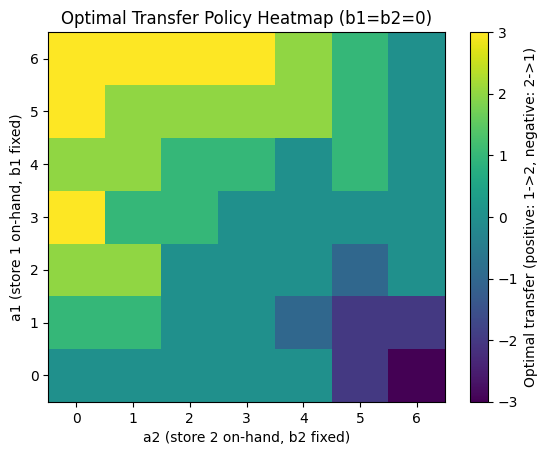

In [18]:
b1 = 0
b2 = 0

C1, C2 = mdp.C1, mdp.C2
transfer_grid = [[0 for _ in range(C2+1)] for __ in range(C1+1)]
order1_grid = [[0 for _ in range(C2+1)] for __ in range(C1+1)]
order2_grid = [[0 for _ in range(C2+1)] for __ in range(C1+1)]

for a1 in range(C1+1):
    for a2 in range(C2+1):
        st = TwoStoreState(a1=a1, b1=b1, a2=a2, b2=b2)
        nt = NonTerminal(st)
        act = pi[nt]
        transfer_grid[a1][a2] = act.transfer
        order1_grid[a1][a2] = act.order1
        order2_grid[a1][a2] = act.order2

plt.figure()
plt.imshow(transfer_grid, origin="lower", aspect="auto")
plt.colorbar(label="Optimal transfer (positive: 1->2, negative: 2->1)")
plt.xlabel("a2 (store 2 on-hand, b2 fixed)")
plt.ylabel("a1 (store 1 on-hand, b1 fixed)")
plt.title("Optimal Transfer Policy Heatmap (b1=b2=0)")
plt.show()


### Policy Intuition Checks (What I looked for)

- If store 2 has larger demand mean (\(\lambda_2 > \lambda_1\)) and/or higher stockout cost (\(p_2 > p_1\)),
  the optimal policy tends to transfer inventory from store 1 to store 2 when store 2 is relatively low on stock.
  This reduces expected stockouts at the more “valuable” store.

- Increasing fixed order cost \(K_1\) makes ordering more “lumpy”: the policy orders less frequently, but when it orders,
  it orders more units (typical fixed-cost / (s,S)-type behavior).

- Increasing fixed transfer cost \(K_2\) reduces transfers and makes the transfer decision threshold-like: transfers occur only
  when the inventory imbalance is large enough to justify paying \(K_2\).

- Higher holding cost \(h_i\) discourages holding excess inventory at store \(i\), often leading to smaller orders for that store
  or more willingness to ship inventory out (if \(K_2\) is not too large).

Overall, the computed optimal policy aligns with the tradeoff between expected stockout losses, holding costs, and fixed transportation costs.


## Question 3: Dynamic Price Optimization (Led by ______)

You own a supermarket, and you are $T$ days away from Halloween 🎃. You have just received $M$ Halloween masks from your supplier. You want to dynamically set the selling price of the Halloween masks at the start of each day in a manner that maximizes your **Expected Total Sales Revenue** for Halloween masks this season (assume no one will buy Halloween masks after Halloween).

Assume that for each of the $T$ days, you are required to select a price for that day from one of $N$ prices $p_1, p_2, \dots, p_N \in \mathbb{R}$, and that price is the selling price for all masks on that day. Assume that the customer demand for the number of Halloween masks on any day is governed by a Poisson probability distribution with mean $\lambda_i \in \mathbb{R}$ if you select that day’s price to be $p_i$ (where $i$ is a choice among $1, 2, \dots, N$).

Note that on any given day, the demand could exceed the number of Halloween masks you have in the store, in which case the number of masks sold on that day will be equal to the number of Halloween masks you had at the start of that day.

We spoke about this example in class - referencing the slides here (if needed) could be helpful!

---

### Subquestions

#### Part (A): Bellman Optimality Equation

Write the **Bellman Optimality Equation** customized to this Markov Decision Process (MDP). Essentially, you need to express the **Optimal Value Function** $v_*$ recursively based on taking the best action in the current state and based on the subsequent random customer demand that would produce the appropriate reward and take you to the next state.

**Note**: The probability mass function of a Poisson distribution with mean $\lambda \in \mathbb{R}$ is given by:

$$
f(k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

---

#### Part (B): Boundary Conditions

To be able to solve the $v_*$ recursion, you need to know the values of $v_*$ for the boundary case (boundary states). Write down the boundary case(s) for the $v_*$ recursion.

---

#### Part (C): Numerical Solution

You can solve this $v_*$ recursion (hence, solve for the **Optimal Policy** $\pi_*$) with a numerical recursive algorithm (essentially a special form of Dynamic Programming algorithm customized to this problem). 

Write Python code for this algorithm that would enable you to dynamically set the selling price at the start of each day. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

---


### Part (A) Answer

### Part (A): Bellman Optimality Equation

Define the state as $(t,m)$ where:

- $t \in \{0,1,\dots,T\}$ is the number of days remaining
- $m \in \{0,1,\dots,M\}$ is the number of masks remaining in inventory

At state $(t,m)$, you choose a price $p_i$ from $\{p_1,\dots,p_N\}$.

If price $p_i$ is chosen, demand $D$ follows:
$$
D \sim \text{Poisson}(\lambda_i)
$$

Sales that day:
$$
S = \min(D, m)
$$

Revenue that day:
$$
R = p_i \cdot S
$$

Next state:
$$
(t-1, m-S)
$$

The optimal value function is:

$$
v_*(t,m)
=
\max_{i \in \{1,\dots,N\}}
\mathbb{E}
\Big[
p_i \min(D,m)
+
v_*(t-1, m-\min(D,m))
\Big]
$$

Expanding the expectation using the Poisson pmf:

$$
v_*(t,m)
=
\max_{i}
\left(
\sum_{k=0}^{\infty}
\frac{e^{-\lambda_i} \lambda_i^k}{k!}
\Big[
p_i \min(k,m)
+
v_*(t-1, m-\min(k,m))
\Big]
\right)
$$


### Part (B) Answer


1. No days remaining:
$$
v_*(0,m) = 0 \quad \text{for all } m
$$

2. No inventory remaining:
$$
v_*(t,0) = 0 \quad \text{for all } t
$$

In both cases, no more masks can be sold, so expected revenue is zero.


### Part (C) Answer

In [16]:
@dataclass(frozen=True)
class PricingDPResult:
    V: List[List[float]]
    Pi: List[List[int]]


def poisson_pmf_up_to(k_max: int, lam: float) -> Tuple[List[float], float]:
    pmf = [0.0] * (k_max + 1)
    pmf[0] = math.exp(-lam)
    for k in range(1, k_max + 1):
        pmf[k] = pmf[k - 1] * lam / k
    tail = max(0.0, 1.0 - sum(pmf))
    return pmf, tail


def solve_halloween_pricing_dp(
    T: int,
    M: int,
    prices: List[float],     # length N
    lambdas: List[float],    # length N
) -> PricingDPResult:
    if T < 0 or M < 0:
        raise ValueError("T and M must be nonnegative.")
    if len(prices) == 0 or len(prices) != len(lambdas):
        raise ValueError("prices and lambdas must be non-empty and same length.")
    if any(lam < 0 for lam in lambdas):
        raise ValueError("All lambdas must be >= 0.")

    N = len(prices)

    # Precompute Poisson pmfs up to M for each price choice.
    # This is essentially exact for DP because sales are capped at m <= M.
    pmfs: List[List[float]] = []
    tails: List[float] = []
    for lam in lambdas:
        pmf, tail = poisson_pmf_up_to(M, lam)
        pmfs.append(pmf)
        tails.append(tail)

    # DP tables: (T+1) x (M+1)
    V = [[0.0 for _ in range(M + 1)] for __ in range(T + 1)]
    Pi = [[0 for _ in range(M + 1)] for __ in range(T + 1)]

    # Boundary conditions already satisfied by initialization:
    # V[0][m] = 0 for all m, and V[t][0] = 0 for all t.

    for t in range(1, T + 1):
        for m in range(1, M + 1):
            best_val = -1e100
            best_i = 0

            for i in range(N):
                p = prices[i]
                pmf = pmfs[i]
                tail = tails[i]

                val = 0.0

                # Sum over demands k=0..M
                # If k >= m then sales=min(k,m)=m, next inventory=0
                for k in range(0, M + 1):
                    prob = pmf[k]
                    s = k if k < m else m
                    val += prob * (p * s + V[t - 1][m - s])

                # Tail event: D > M implies D >= M+1 >= m (since m <= M)
                # So sales = m, next inventory = 0 exactly.
                if tail > 0.0:
                    val += tail * (p * m + V[t - 1][0])

                if val > best_val:
                    best_val = val
                    best_i = i

            V[t][m] = best_val
            Pi[t][m] = best_i

    return PricingDPResult(V=V, Pi=Pi)


def extract_price_path(
    res: PricingDPResult,
    T: int,
    M: int,
    prices: List[float]
) -> List[float]:
    path: List[float] = []
    m = M
    for t in range(T, 0, -1):
        i = res.Pi[t][m]
        path.append(prices[i])
        # inventory evolution is stochastic, so we do not update m here.
        # In real use, after observing sales S you would set m <- m - S.
    return path


In [17]:

T = 14
M = 50
prices = [2.0, 3.0, 4.0, 5.0]
lambdas = [30.0, 20.0, 14.0, 10.0]

res = solve_halloween_pricing_dp(T, M, prices, lambdas)

print("Optimal expected revenue from start (T,M):", res.V[T][M])
print("Optimal price today:", prices[res.Pi[T][M]])

# Show optimal price as function of inventory for a fixed t
t = T
for m in [0, 5, 10, 20, 30, 40, 50]:
    print(f"t={t}, m={m}, best price = {prices[res.Pi[t][m]]}")


Optimal expected revenue from start (T,M): 250.00000000000017
Optimal price today: 5.0
t=14, m=0, best price = 2.0
t=14, m=5, best price = 5.0
t=14, m=10, best price = 5.0
t=14, m=20, best price = 5.0
t=14, m=30, best price = 5.0
t=14, m=40, best price = 5.0
t=14, m=50, best price = 5.0


## Question 4: Risk-Aversion and Utility Optimization under CARA Utility (Led by ______)

You are tasked with analyzing the behavior of an investor who seeks to maximize their utility under **CARA Utility**. The investor has wealth $W$ and the CARA utility function:

$$
U(W) = \frac{1 - e^{-aW}}{a}, \quad a > 0,
$$

where $a$ represents the investor's **risk aversion**.

The investor allocates their wealth between:
1. A **riskless asset** with a fixed return $r$, and
2. A **risky asset** with return $R \sim \mathcal{N}(\mu, \sigma^2)$

The investor allocates a fraction $\pi$ of their wealth to the risky asset and $(1 - \pi)$ to the riskless asset. The wealth $W$ after one year is given by:

$$
W = (1 + r)(1 - \pi) + (1 + R)\pi.
$$

The goal is to analyze the investor’s optimal allocation $\pi$ to the risky asset and compute key risk-related quantities.

---

### Subquestions

#### Part (A): Expected Utility and Certainty-Equivalent Wealth

1. Derive the expression for the **expected utility** $\mathbb{E}[U(W)]$, using the given CARA utility function and assuming $R \sim \mathcal{N}(\mu, \sigma^2)$.
2. Using a Taylor expansion, approximate the **certainty-equivalent wealth** $W_{CE}$ up to second-order terms.

---

#### Part (B): Optimal Portfolio Allocation

Derive the optimal fraction $\pi^*$ of wealth to be allocated to the risky asset such that the **expected utility** $\mathbb{E}[U(W)]$ is maximized. Express $\pi^*$ in terms of $a$, $\mu$, $r$, and $\sigma^2$.

---

#### Part (C): Risk Premium

1. Using the results from Part (A), calculate the **absolute risk premium** $\pi_A = \mathbb{E}[W] - W_{CE}$.
2. Verify that $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ for small $\sigma^2$.

---

#### Part (D): Numerical Calculations and Interpretation

Given the parameters $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, and $a = 3$:
1. Compute the optimal allocation $\pi^*$.
2. Calculate the certainty-equivalent wealth $W_{CE}$.
3. Compute the absolute risk premium $\pi_A$.
4. Interpret the results and discuss how changes in $a$ and $\sigma^2$ affect the risk premium and portfolio allocation.

---

#### Part (E): Expected Utility under Uniform Distribution

Now assume that the return of the risky asset, $R$, is no longer normally distributed. Instead, $R \sim \text{Uniform}[\alpha, \beta]$, where $\alpha$ and $\beta$ are the lower and upper bounds of the distribution, respectively.

1. Derive the new expression for the **expected utility** $\mathbb{E}[U(W)]$. Make sure to simplify your result as much as possible, and ensure that it explicitly depends on $a$, $\pi$, $\alpha$, $\beta$, and $r$.

**Hint**: Use the fact that if $W \sim \text{Uniform}[w_{\text{min}}, w_{\text{max}}]$, then:

$$
\mathbb{E}[g(W)] = \frac{1}{w_{\text{max}} - w_{\text{min}}} \int_{w_{\text{min}}}^{w_{\text{max}}} g(W) \, dW.
$$

---

### Part (A) Answer

## Part (A): Expected Utility and Certainty-Equivalent Wealth

### (A1) Expected Utility when $R\sim \mathcal N(\mu,\sigma^2)$

Let $X:=R-r$. Then $X\sim \mathcal N(\mu-r,\sigma^2)$ and
$$
W=(1+r)+\pi X.
$$
Hence
$$
\mathbb E[U(W)]
=\frac{1-\mathbb E[e^{-aW}]}{a}
=\frac{1-e^{-a(1+r)}\mathbb E\!\left[e^{-a\pi X}\right]}{a}.
$$
Using the MGF of a normal, for $X\sim \mathcal N(m,s^2)$,
$$
\mathbb E[e^{tX}] = \exp\left(mt+\frac{s^2 t^2}{2}\right),
$$
so with $t=-a\pi$, $m=\mu-r$, $s^2=\sigma^2$:
$$
\mathbb E[e^{-a\pi X}]
=\exp\left(-(a\pi)(\mu-r)+\frac{(a\pi)^2\sigma^2}{2}\right).
$$
Therefore
$$
\mathbb E[U(W)]
=\frac{1-\exp\left(-a(1+r)-a\pi(\mu-r)+\frac{a^2\pi^2\sigma^2}{2}\right)}{a}.
$$

### (A2) Certainty-Equivalent Wealth $W_{CE}$ (second-order)

Define $W_{CE}$ by
$$
U(W_{CE})=\mathbb E[U(W)].
$$
Since $U$ is strictly increasing, this is equivalent to
$$
e^{-a W_{CE}}=\mathbb E[e^{-aW}].
$$
Thus
$$
W_{CE}=-\frac{1}{a}\log\mathbb E[e^{-aW}].
$$
From above,
$$
\mathbb E[e^{-aW}]
=\exp\left(-a(1+r)-a\pi(\mu-r)+\frac{a^2\pi^2\sigma^2}{2}\right),
$$
so
$$
W_{CE}
=(1+r)+\pi(\mu-r)-\frac{a\pi^2\sigma^2}{2}.
$$


### Part (B) Answer

Maximizing $\mathbb E[U(W)]$ is equivalent to maximizing $W_{CE}$ (monotone transform).
Using
$$
W_{CE}=(1+r)+\pi(\mu-r)-\frac{a\pi^2\sigma^2}{2},
$$
differentiate w.r.t. $\pi$ and set to zero:
$$
\frac{d}{d\pi}W_{CE}=(\mu-r)-a\pi\sigma^2=0
\quad\Rightarrow\quad
\pi^*=\frac{\mu-r}{a\sigma^2}.
$$


### Part (C) Answer

### (C1) Absolute risk premium

$$
\pi_A := \mathbb E[W]-W_{CE}.
$$
We have
$$
\mathbb E[W]=(1+r)+\pi(\mu-r),
\qquad
W_{CE}=(1+r)+\pi(\mu-r)-\frac{a\pi^2\sigma^2}{2},
$$
so
$$
\pi_A=\frac{a\pi^2\sigma^2}{2}.
$$

### (C2) Verification for small $\sigma^2$

The second-order approximation gives
$$
W_{CE}\approx \mathbb E[W]-\frac{a}{2}\mathrm{Var}(W)
=\mathbb E[W]-\frac{a}{2}\pi^2\sigma^2,
$$
hence
$$
\pi_A=\mathbb E[W]-W_{CE}\approx \frac{a\pi^2\sigma^2}{2}.
$$

### Part (D) Answer

### (D1) Optimal allocation
$$
\pi^*=\frac{\mu-r}{a\sigma^2}
=\frac{0.08-0.02}{3\cdot 0.04}
=\frac{0.06}{0.12}
=0.5.
$$

### (D2) Certainty-equivalent wealth at $\pi^*$
First compute
$$
\mathbb E[W]=(1+r)+\pi^*(\mu-r)=1.02+0.5\cdot 0.06=1.05.
$$
Then
$$
W_{CE}= \mathbb E[W]-\frac{a(\pi^*)^2\sigma^2}{2}
=1.05-\frac{3\cdot (0.5)^2\cdot 0.04}{2}
=1.05-\frac{3\cdot 0.25\cdot 0.04}{2}
=1.05-\frac{0.03}{2}
=1.035.
$$

### (D3) Absolute risk premium at $\pi^*$
$$
\pi_A=\mathbb E[W]-W_{CE}=1.05-1.035=0.015.
$$

### (D4) Interpretation

- $\pi^*=0.5$ means invest 50% in risky asset and 50% in riskless asset.
- The certainty-equivalent wealth is $W_{CE}=1.035$, which is lower than the mean wealth $1.05$ due to risk.
- The absolute risk premium is $\pi_A=0.015$: the investor would give up 0.015 units of certain wealth to avoid the risk.

Comparative statics:
- If $a$ increases, then $\pi^*=\frac{\mu-r}{a\sigma^2}$ decreases and $\pi_A=\frac{a\pi^2\sigma^2}{2}$ increases (more risk-averse implies smaller risky allocation and higher compensation required for risk).
- If $\sigma^2$ increases, then $\pi^*$ decreases (riskier asset -> invest less), and for fixed $\pi$ the risk premium increases linearly in $\sigma^2$.


### Part (E) Answer

Now
$$
W=(1+r)+\pi(R-r).
$$
Since $R\in[\alpha,\beta]$, the support of $W$ is
$$
w_{\min}=(1+r)+\pi(\alpha-r),\qquad
w_{\max}=(1+r)+\pi(\beta-r).
$$
Expected utility:
$$
\mathbb E[U(W)]
=\frac{1}{\beta-\alpha}\int_{\alpha}^{\beta}\frac{1-e^{-a[(1+r)+\pi(x-r)]}}{a}\,dx
=\frac{1}{a}-\frac{1}{a(\beta-\alpha)}\int_{\alpha}^{\beta}e^{-a(1+r)}e^{-a\pi(x-r)}\,dx.
$$
Compute the integral (for $\pi\neq 0$):
$$
\int_{\alpha}^{\beta} e^{-a\pi(x-r)}\,dx
=\left[-\frac{1}{a\pi}e^{-a\pi(x-r)}\right]_{\alpha}^{\beta}
=\frac{1}{a\pi}\left(e^{-a\pi(\alpha-r)}-e^{-a\pi(\beta-r)}\right).
$$
Therefore, for $\pi\neq 0$:
$$
\mathbb E[U(W)]
=
\frac{1}{a}
-\frac{e^{-a(1+r)}}{a(\beta-\alpha)}\cdot
\frac{1}{a\pi}\left(e^{-a\pi(\alpha-r)}-e^{-a\pi(\beta-r)}\right).
$$
Equivalently,
$$
\mathbb E[U(W)]
=
\frac{1}{a}
-\frac{e^{-a(1+r)}}{a^2\pi(\beta-\alpha)}
\left(e^{-a\pi(\alpha-r)}-e^{-a\pi(\beta-r)}\right).
$$

Boundary case $\pi=0$:
$$
W=1+r \ \Rightarrow\ \mathbb E[U(W)]=U(1+r)=\frac{1-e^{-a(1+r)}}{a}.
$$